<a href="https://colab.research.google.com/github/samikshanimje/SmartECG-HD/blob/main/notebooks/01_data_acquisition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartECG-HD

## Notebook 01 — Data Acquisition

### Objectives

- Download ECG records from PhysioNet
- Read ECG signals
- Read annotations
- Visualize ECG waveforms
- Understand beat labels
- Prepare data for preprocessing

Author: Samiksha Nimje

In [5]:
!pip -q install wfdb neurokit2 imbalanced-learn pywavelets

In [8]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
import neurokit2 as nk

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
PROJECT_NAME = "SmartECG-HD"

DATASET = "MIT-BIH Arrhythmia"

SAMPLING_RATE = 360

WINDOW_SIZE = 300

print(f"Project : {PROJECT_NAME}")
print(f"Dataset : {DATASET}")
print(f"Sampling Rate : {SAMPLING_RATE} Hz")

Project : SmartECG-HD
Dataset : MIT-BIH Arrhythmia
Sampling Rate : 360 Hz


In [11]:
import os
import wfdb

DATA_DIR = "datasets/mitbih"

os.makedirs(DATA_DIR, exist_ok=True)

record = "100"

wfdb.dl_database(
    "mitdb",
    dl_dir=DATA_DIR,
    records=[record]
)

print("Dataset downloaded successfully.")

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Dataset downloaded successfully.


In [12]:
record_path = os.path.join(DATA_DIR, "100")

record = wfdb.rdrecord(record_path)

print(record)

In [13]:
annotation = wfdb.rdann(record_path, "atr")

print(annotation)

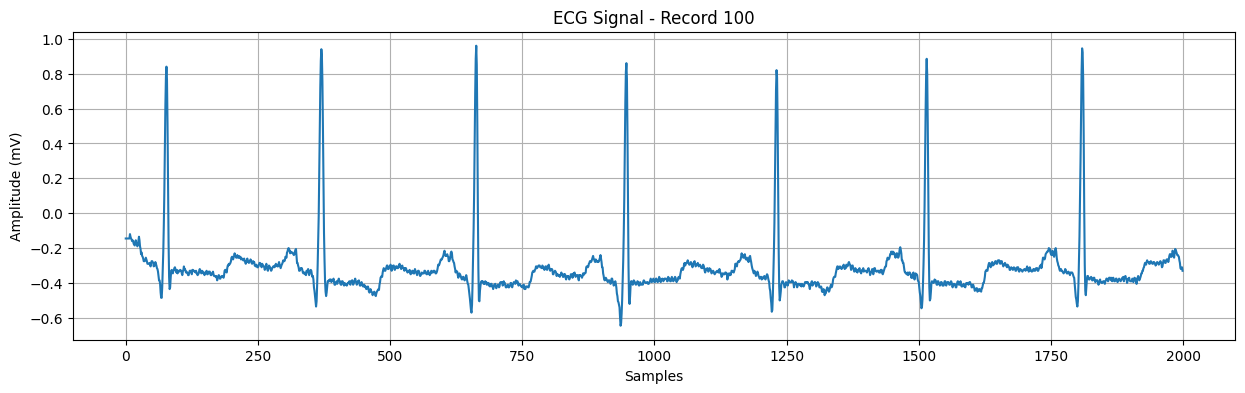

In [14]:
signal = record.p_signal[:, 0]

plt.figure(figsize=(15, 4))
plt.plot(signal[:2000])
plt.title("ECG Signal - Record 100")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

In [15]:
MITBIH_RECORDS = [
    "100","101","102","103","104","105","106","107",
    "108","109","111","112","113","114","115","116",
    "117","118","119","121","122","123","124","200",
    "201","202","203","205","207","208","209","210",
    "212","213","214","215","217","219","220","221",
    "222","223","228","230","231","232","233","234"
]

print("Total Records:", len(MITBIH_RECORDS))

Total Records: 48


In [ ]:
import wfdb
import os

DATA_DIR = "datasets/mitbih"

os.makedirs(DATA_DIR, exist_ok=True)

for record in MITBIH_RECORDS:
    wfdb.dl_database(
        "mitdb",
        dl_dir=DATA_DIR,
        records=[record]
    )

print("All records downloaded successfully!")

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 102
Generating list of all files for: 102
Finished downloading files
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Generating record list for: 104
Generating list of all files for: 104
Finished downloading files
Generating record list for: 105
Generating list of all files for: 105
Finished downloading files
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
Generating record list for: 107
Generating list of all files for: 107
Finished downloading files
Generating record list for: 108
Generating list of all files for: 108
Finished downloading files
Generating record list for: 109
Generating list of all files for: 109
Finished downloading files
Generating record list for: 11

In [ ]:
import os

files = os.listdir(DATA_DIR)

print(f"Total files: {len(files)}")
print(files[:15])

In [ ]:
def load_record(record_id):

    path = os.path.join(DATA_DIR, record_id)

    record = wfdb.rdrecord(path)

    annotation = wfdb.rdann(path, "atr")

    return record, annotation

In [ ]:
record, annotation = load_record("100")

print(record.sig_len)
print(len(annotation.sample))

In [ ]:
signal = record.p_signal[:,0]

print("Signal Shape :", signal.shape)

print("Sampling Rate :", record.fs)

print("Channels :", record.sig_name)

In [ ]:
import pandas as pd

labels = pd.Series(annotation.symbol)

print(labels.value_counts())